# Sähkön hinta: juurisyyanalyysi

Miksi sähkölasku voi nousta, vaikka keskihinta laskee?

Vertaillaan yksinkertaista ja kulutuksella painotettua keskihintaa
Suomen spot-hinnoilla ja kansallisella kulutusdatalla.

**Lähteet**
- Spot-hinnat: sahkotin.fi (Pakastin Oy), data Nord Pool
- Kulutus: Fingrid avoin data, dataset 124 (CC 4.0 BY)

## 1. Setup

In [175]:
import os
import time
import requests
import pandas as pd
from dotenv import load_dotenv

load_dotenv(dotenv_path="../.env")

avain = os.getenv("FINGRID_API_KEY")
print("avain ladattu:", avain is not None, "| pituus:", len(avain) if avain else 0)

avain ladattu: True | pituus: 32


## 2. Apufunktiot

Hinnat haetaan ilman ALV:ta, koska yritys vähentää sen ja
ALV-kanta muuttui 9/2024 (24 % -> 25,5 %). ALV:llisilla hinnoilla
osa vuosimuutoksesta olisi verotusta, ei markkinaa.

In [176]:
def tarkista(df, nimi, odotettu_rivit, sarake):
    """Datan laatutarkistus: rivimäärä, puuttuvat, duplikaatit, jakauma."""
    print(f"--- {nimi} ---")
    print("rivejä:", len(df), "| odotettu:", odotettu_rivit)
    print("puuttuvia:", df.isna().sum().sum())
    print("duplikaatteja:", df["ts"].duplicated().sum())
    print("aikaväli:", df["ts"].min(), "->", df["ts"].max())
    print(df[sarake].describe())

In [177]:
def hae_hinnat(start, end):
    """Spot-hinnat sahkotin.fi:stä, snt/kWh ilman ALV:ta, UTC."""
    r = requests.get("https://sahkotin.fi/prices", params={
        "start": start,
        "end": end,
        "fix": ""          # €/MWh -> snt/kWh; ei vat-parametria
    }, timeout=30)
    r.raise_for_status()

    df = pd.DataFrame(r.json()["prices"])
    df["ts"] = pd.to_datetime(df["date"], utc=True)
    return (df[["ts", "value"]]
            .rename(columns={"value": "price_snt_kwh"})
            .sort_values("ts")
            .reset_index(drop=True))

In [178]:
def hae_kulutus(start, end, dataset_id=124):
    """Suomen sähkönkulutus Fingridiltä, MWh/h, 15 min resoluutio, UTC."""
    rows, page = [], 1
    while True:
        r = requests.get(
            f"https://data.fingrid.fi/api/datasets/{dataset_id}/data",
            headers={"x-api-key": os.getenv("FINGRID_API_KEY")},
            params={"startTime": start, "endTime": end,
                    "pageSize": 20000, "page": page,
                    "sortBy": "startTime", "sortOrder": "asc"},
            timeout=60)
        r.raise_for_status()
        payload = r.json()
        rows.extend(payload["data"])

        p = payload["pagination"]
        if p["currentPage"] >= p["lastPage"]:
            print(f"  Fingrid: {p['total']} riviä, {p['lastPage']} sivua")
            break
        page += 1
        time.sleep(7)      # kiintiö 10 kutsua/min

    df = pd.DataFrame(rows)
    df["ts"] = pd.to_datetime(df["startTime"], utc=True)
    return (df[["ts", "value"]]
            .rename(columns={"value": "consumption_mwh"})
            .sort_values("ts")
            .reset_index(drop=True))

## 3. Datan haku ja tarkistus

Testataan ensin yhdellä kuukaudella (tammikuu 2024 = 744 tuntia)
ennen koko aikavälin hakua.

In [179]:
prices = hae_hinnat("2024-01-01T00:00:00.000Z", "2024-02-01T00:00:00.000Z")
tarkista(prices, "Hinnat 1/2024", 744, "price_snt_kwh")

--- Hinnat 1/2024 ---
rivejä: 744 | odotettu: 744
puuttuvia: 0
duplikaatteja: 0
aikaväli: 2024-01-01 00:00:00+00:00 -> 2024-01-31 23:00:00+00:00
count    744.000000
mean      10.616461
std       18.693882
min       -0.207000
25%        3.156750
50%        7.814500
75%       11.009750
max      189.600000
Name: price_snt_kwh, dtype: float64


In [180]:
raaka = hae_kulutus("2024-01-01T00:00:00Z", "2024-02-01T00:00:00Z")

print("raakarivejä:", len(raaka), "| odotettu 15 min:", 744 * 4)
print("aikaväli:", raaka["ts"].min(), "->", raaka["ts"].max())

  Fingrid: 2976 riviä, 1 sivua
raakarivejä: 2976 | odotettu 15 min: 2976
aikaväli: 2024-01-01 00:00:00+00:00 -> 2024-01-31 23:45:00+00:00


### Kulutuksen aggregointi tunneiksi

Kulutus on varttitasolla (13.6.2023 alkaen), hinnat tuntitasolla
1.10.2025 asti. Yhdenmukaistetaan tuntitasolle.

Aggregointi tehdään **keskiarvona, ei summana**: MWh/h on teho, ei
energia. Neljän vartin keskiarvo antaa tunnin keskitehon, joka
MWh/h-yksikössä vastaa tunnin energiaa. Summaus antaisi
nelinkertaisen kulutuksen.

In [181]:
consumption = (raaka.set_index("ts")
                    .resample("1h")["consumption_mwh"]
                    .mean()
                    .reset_index())

tarkista(consumption, "Kulutus 1/2024", 744, "consumption_mwh")

--- Kulutus 1/2024 ---
rivejä: 744 | odotettu: 744
puuttuvia: 0
duplikaatteja: 0
aikaväli: 2024-01-01 00:00:00+00:00 -> 2024-01-31 23:00:00+00:00
count      744.000000
mean     12426.091509
std       1128.159631
min       9530.455000
25%      11615.812500
50%      12430.762500
75%      13295.925000
max      14995.850000
Name: consumption_mwh, dtype: float64


## 4. Koko aikavälin haku (2024–2025)

Haetaan kuukausi kerrallaan ja tallennetaan levylle, jottei
API:a tarvitse kuormittaa uudelleen analyysin aikana.
Raakadata ei mene versionhallintaan (.gitignore).

In [182]:
from pathlib import Path

RAW = Path("../data/raw")
RAW.mkdir(parents=True, exist_ok=True)

def kuukaudet(alkuvuosi, loppuvuosi):
    """Palauttaa (start, end) -parit kuukausittain, end eksklusiivinen."""
    rajat = pd.date_range(f"{alkuvuosi}-01-01", f"{loppuvuosi+1}-01-01",
                          freq="MS", tz="UTC")
    return [(a.strftime("%Y-%m-%dT%H:%M:%S.000Z"),
             b.strftime("%Y-%m-%dT%H:%M:%S.000Z"))
            for a, b in zip(rajat[:-1], rajat[1:])]

jaksot = kuukaudet(2024, 2025)
print("kuukausia:", len(jaksot))

kuukausia: 24


In [183]:
hinta_tiedosto = RAW / "prices_2024_2025.parquet"

if hinta_tiedosto.exists():
    prices_all = pd.read_parquet(hinta_tiedosto)
    print("luettu levyltä")
else:
    osat = []
    for a, b in jaksot:
        osat.append(hae_hinnat(a, b))
        print(".", end="")
    prices_all = pd.concat(osat).sort_values("ts").reset_index(drop=True)
    prices_all.to_parquet(hinta_tiedosto)
    print(" haettu API:sta")

tarkista(prices_all, "Hinnat 2024-2025", 366*24 + 365*24, "price_snt_kwh")

luettu levyltä
--- Hinnat 2024-2025 ---
rivejä: 17544 | odotettu: 17544
puuttuvia: 0
duplikaatteja: 0
aikaväli: 2024-01-01 00:00:00+00:00 -> 2025-12-31 23:00:00+00:00
count    17544.000000
mean         4.303201
std          6.454367
min         -2.139000
25%          0.401000
50%          2.344000
75%          6.385750
max        189.600000
Name: price_snt_kwh, dtype: float64


In [184]:
kulutus_tiedosto = RAW / "consumption_2024_2025.parquet"

if kulutus_tiedosto.exists():
    consumption_all = pd.read_parquet(kulutus_tiedosto)
    print("luettu levyltä")
else:
    osat = []
    for a, b in jaksot:
        osat.append(hae_kulutus(a, b))
        time.sleep(7)
    raaka_all = pd.concat(osat).sort_values("ts").reset_index(drop=True)
    consumption_all = (raaka_all.set_index("ts")
                                .resample("1h")["consumption_mwh"]
                                .mean()
                                .reset_index())
    consumption_all.to_parquet(kulutus_tiedosto)
    print("haettu API:sta")

tarkista(consumption_all, "Kulutus 2024-2025", 366*24 + 365*24, "consumption_mwh")

luettu levyltä
--- Kulutus 2024-2025 ---
rivejä: 17544 | odotettu: 17544
puuttuvia: 1
duplikaatteja: 0
aikaväli: 2024-01-01 00:00:00+00:00 -> 2025-12-31 23:00:00+00:00
count    17543.000000
mean      9491.516398
std       1571.593601
min       5778.950000
25%       8318.983750
50%       9248.915000
75%      10593.525000
max      14995.850000
Name: consumption_mwh, dtype: float64


## 5. Yhdistäminen ja aikavyöhyke

Molemmat sarjat ovat UTC:ssä. Muunnetaan Suomen aikaan ennen
laskentaa: "kallis tunti" on paikallisen ajan käsite, ja
kesäaikasiirtymä siirtäisi sen väärään kohtaan.

Kulutusdatassa on yksi tunti (6/2024), jolta puuttuvat kaikki neljä
varttia. Se pudotetaan; puuttuvia arvoja ei interpoloida, koska
keksitty kulutuslukema menisi suoraan painotettuun keskihintaan.

Data haettiin UTC-kalenterivuosina, joten aikavyöhykemuunnoksen
jälkeen mukaan lipsahtaa kaksi tuntia vuodelta 2026. Rajataan
täysiin paikallisiin vuosiin 2024–2025.

In [185]:
p = prices_all.copy()
c = consumption_all.copy()

for df in (p, c):
    df["ts"] = df["ts"].dt.tz_convert("Europe/Helsinki")

data = p.merge(c, on="ts", how="inner")

print("hinnat:", len(p), "| kulutus:", len(c), "| yhdistetty:", len(data))

data = data.dropna(subset=["consumption_mwh", "price_snt_kwh"])
print("pudotuksen jälkeen:", len(data))

data["hour"]  = data["ts"].dt.hour
data["dow"]   = data["ts"].dt.dayofweek
data["month"] = data["ts"].dt.month
data["year"]  = data["ts"].dt.year

data = data[data["year"].isin([2024, 2025])].copy()
print("rajattu täysiin paikallisiin vuosiin:", len(data))

data.head()

hinnat: 17544 | kulutus: 17544 | yhdistetty: 17544
pudotuksen jälkeen: 17543
rajattu täysiin paikallisiin vuosiin: 17541


,ts,price_snt_kwh,consumption_mwh,hour,dow,month,year
0,2024-01-01 02:00:00+02:00,2.846,12284.775,2,0,1,2024
1,2024-01-01 03:00:00+02:00,2.666,12167.450,3,0,1,2024
2,2024-01-01 04:00:00+02:00,2.448,12186.150,4,0,1,2024
3,2024-01-01 05:00:00+02:00,2.401,12245.050,5,0,1,2024
4,2024-01-01 06:00:00+02:00,2.123,12411.325,6,0,1,2024


## 6. Yksinkertainen vs. painotettu keskihinta

Yksinkertainen keskihinta kohtelee jokaista tuntia samanarvoisena.
Painotettu keskihinta painottaa tunteja kulutuksen mukaan — eli
kertoo, mitä sähköstä oikeasti maksettiin.

In [186]:
def keskihinnat(g):
    return pd.Series({
        "yksinkertainen": g["price_snt_kwh"].mean(),
        "painotettu": (g["price_snt_kwh"] * g["consumption_mwh"]).sum()
                      / g["consumption_mwh"].sum()
    })

tulos = data.groupby("year")[["price_snt_kwh", "consumption_mwh"]].apply(keskihinnat)
tulos["ero_snt"] = tulos["painotettu"] - tulos["yksinkertainen"]
tulos["ero_%"]   = (tulos["painotettu"] / tulos["yksinkertainen"] - 1) * 100

print(tulos.round(3))

      yksinkertainen  painotettu  ero_snt  ero_%
year                                            
2024           4.557       4.990    0.434  9.516
2025           4.047       4.158    0.111  2.738


## 7. Herkkyystarkastelu

Tammikuussa 2024 spot-hinta kävi 189,6 snt/kWh:ssa. Testataan,
selittääkö yksittäinen poikkeusjakso koko preemion vai onko ilmiö
rakenteellinen.

In [187]:
raja = data["price_snt_kwh"].quantile(0.99)
ilman = data[data["price_snt_kwh"] <= raja]

vertailu = pd.concat([
    data.groupby("year")[["price_snt_kwh","consumption_mwh"]].apply(keskihinnat),
    ilman.groupby("year")[["price_snt_kwh","consumption_mwh"]].apply(keskihinnat)
], axis=1, keys=["kaikki", "ilman_kalleinta_1%"])

print("raja:", round(raja,2), "snt/kWh")
print(vertailu.round(3))

raja: 25.0 snt/kWh
             kaikki            ilman_kalleinta_1%           
     yksinkertainen painotettu     yksinkertainen painotettu
year                                                        
2024          4.557      4.990              4.065      4.370
2025          4.047      4.158              3.851      3.966


In [188]:
kallis = data.nlargest(50, "price_snt_kwh")
print(kallis.groupby([kallis["ts"].dt.year, kallis["ts"].dt.month]).size())

ts    ts
2024  1     20
      5      3
      9      5
      10     9
      12     3
2025  1      1
      3      2
      4      2
      8      3
      10     2
dtype: int64


In [189]:
# 1. Hintavaihtelu: paljonko kalliit ja halvat tunnit eroavat?
vaihtelu = data.groupby("year")["price_snt_kwh"].agg(
    keskiarvo="mean",
    keskihajonta="std",
    p90=lambda s: s.quantile(0.90),
    p10=lambda s: s.quantile(0.10),
)
vaihtelu["p90_p10_ero"] = vaihtelu["p90"] - vaihtelu["p10"]
vaihtelu["variaatiokerroin"] = vaihtelu["keskihajonta"] / vaihtelu["keskiarvo"]
print(vaihtelu.round(3))

      keskiarvo  keskihajonta     p90    p10  p90_p10_ero  variaatiokerroin
year                                                                       
2024      4.557         7.444  10.609  0.000       10.609             1.634
2025      4.047         5.267  11.191  0.061       11.131             1.302


In [190]:
# 2. Ristiinlaskenta: 2024:n profiili 2025:n hinnoilla ja päinvastoin
def painotettu(hinnat, painot):
    return (hinnat.values * painot.values).sum() / painot.values.sum()

# tuntiprofiili = keskimääräinen kulutus kellonajoittain
profiilit = data.groupby(["year","hour"])["consumption_mwh"].mean().unstack(0)
hinnat_h  = data.groupby(["year","hour"])["price_snt_kwh"].mean().unstack(0)

for hv in (2024, 2025):
    for kv in (2024, 2025):
        p = painotettu(hinnat_h[hv], profiilit[kv])
        print(f"hinnat {hv}, profiili {kv}: {p:.3f}")

hinnat 2024, profiili 2024: 4.621
hinnat 2024, profiili 2025: 4.613
hinnat 2025, profiili 2024: 4.108
hinnat 2025, profiili 2025: 4.100


In [191]:
def hajota(g):
    yks = g["price_snt_kwh"].mean()
    tod = (g["price_snt_kwh"] * g["consumption_mwh"]).sum() / g["consumption_mwh"].sum()

    # tuntikomponentti: kellonaikaprofiili, kausivaihtelu poistettu
    h = g.groupby("hour").agg(hinta=("price_snt_kwh","mean"),
                              kul=("consumption_mwh","mean"))
    tunti = (h["hinta"] * h["kul"]).sum() / h["kul"].sum()

    # kuukausikomponentti
    m = g.groupby("month").agg(hinta=("price_snt_kwh","mean"),
                               kul=("consumption_mwh","mean"))
    kk = (m["hinta"] * m["kul"]).sum() / m["kul"].sum()

    return pd.Series({
        "yksinkertainen": yks,
        "todellinen": tod,
        "preemio": tod - yks,
        "tunti_osuus": tunti - yks,
        "kuukausi_osuus": kk - yks,
    })

print(data.groupby("year")[["price_snt_kwh","consumption_mwh","hour","month"]]
          .apply(hajota).round(3))

      yksinkertainen  todellinen  preemio  tunti_osuus  kuukausi_osuus
year                                                                  
2024           4.557       4.990    0.434        0.065           0.275
2025           4.047       4.158    0.111        0.053           0.081


In [192]:
# Vipu 1: tuntisiirtymä (vuorokauden sisällä)
def tuntisiirto(g, osuus=0.10):
    kallis = g["price_snt_kwh"] >= g["price_snt_kwh"].quantile(0.75)
    halpa  = g["price_snt_kwh"] <= g["price_snt_kwh"].quantile(0.25)

    k = g.copy()
    siirto = k.loc[kallis, "consumption_mwh"].sum() * osuus
    k.loc[kallis, "consumption_mwh"] *= (1 - osuus)
    k.loc[halpa,  "consumption_mwh"] += siirto / halpa.sum()

    ennen = (g["price_snt_kwh"]*g["consumption_mwh"]).sum()/g["consumption_mwh"].sum()
    jalk  = (k["price_snt_kwh"]*k["consumption_mwh"]).sum()/k["consumption_mwh"].sum()
    return pd.Series({"ennen": ennen, "jälkeen": jalk, "säästö_%": (1-jalk/ennen)*100})

print(data.groupby("year")[["price_snt_kwh","consumption_mwh"]]
          .apply(tuntisiirto).round(3))

      ennen  jälkeen  säästö_%
year                          
2024  4.990    4.645     6.926
2025  4.158    3.859     7.185


In [193]:
kk = data.groupby(["year","month"]).agg(
    hinta=("price_snt_kwh","mean"),
    kulutus=("consumption_mwh","mean"),
)

kk["osuus_kulutuksesta_%"] = (
    kk["kulutus"] / kk.groupby("year")["kulutus"].transform("sum") * 100
)

kk["hinta_vs_vuosi_%"] = (
    kk["hinta"] / kk.groupby("year")["hinta"].transform("mean") - 1
) * 100

print(kk.round(2))

            hinta   kulutus  osuus_kulutuksesta_%  hinta_vs_vuosi_%
year month                                                         
2024 1      10.65  12433.50                 11.10            133.34
     2       5.16  11420.02                 10.19             13.06
     3       5.93   9717.25                  8.67             30.03
     4       4.89   9186.95                  8.20              7.20
     5       3.52   8049.11                  7.18            -22.86
     6       3.59   7594.96                  6.78            -21.27
     7       1.68   7730.19                  6.90            -63.22
     8       1.25   8086.26                  7.22            -72.54
     9       5.60   8031.88                  7.17             22.80
     10      4.06   9007.43                  8.04            -10.94
     11      4.53   9976.73                  8.91             -0.65
     12      3.88  10796.92                  9.64            -14.94
2025 1       5.28  11228.96                  9.6

## 8. Suosituksen kvantifiointi

Paljonko säästyisi, jos 10 % kalleimman neljänneksen kulutuksesta
siirtyisi halvimpaan? Lasketaan kaksi versiota:

1. **Teoreettinen yläraja** — kallis ja halpa määritellään koko
   vuoden hinnoista. Siirto tapahtuisi myös tammikuulta heinäkuulle,
   mitä lämmityksen kanssa ei voi tehdä.
2. **Vuorokauden sisällä** — kallis ja halpa määritellään saman
   päivän hinnoista. Tämä on se, mitä kotitalous tai yritys voi
   oikeasti toteuttaa.

In [194]:
def tuntisiirto_vrk(g, osuus=0.10):
    k = g.copy()
    k["pv"] = k["ts"].dt.date
    # kallis/halpa suhteessa saman päivän hintoihin
    k["p_rank"] = k.groupby("pv")["price_snt_kwh"].rank(pct=True)
    kallis, halpa = k["p_rank"] >= 0.75, k["p_rank"] <= 0.25

    siirto = k.loc[kallis, "consumption_mwh"].sum() * osuus
    k.loc[kallis, "consumption_mwh"] *= (1 - osuus)
    k.loc[halpa,  "consumption_mwh"] += siirto / halpa.sum()

    e = (g["price_snt_kwh"]*g["consumption_mwh"]).sum()/g["consumption_mwh"].sum()
    j = (k["price_snt_kwh"]*k["consumption_mwh"]).sum()/k["consumption_mwh"].sum()
    return pd.Series({"ennen": e, "jälkeen": j, "säästö_%": (1-j/e)*100})

print(data.groupby("year")[["ts","price_snt_kwh","consumption_mwh"]]
          .apply(tuntisiirto_vrk, include_groups=False).round(3))

      ennen  jälkeen  säästö_%
year                          
2024  4.990    4.814     3.538
2025  4.158    3.987     4.117


## 9. Kuvaajat

Neljä kuvaajaa, jokainen yhtä väitettä varten. Otsikot ja
akselinimet englanniksi, koska kuvat päätyvät README:hen.
Tallennetaan figures/-kansioon.

In [195]:
import matplotlib.pyplot as plt

FIG = Path("../figures")
FIG.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 130,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

V24, V25 = "#4C72B0", "#DD8452"
HARMAA, VIHREA, PUNAINEN = "#B0B0B0", "#55A868", "#C44E52"

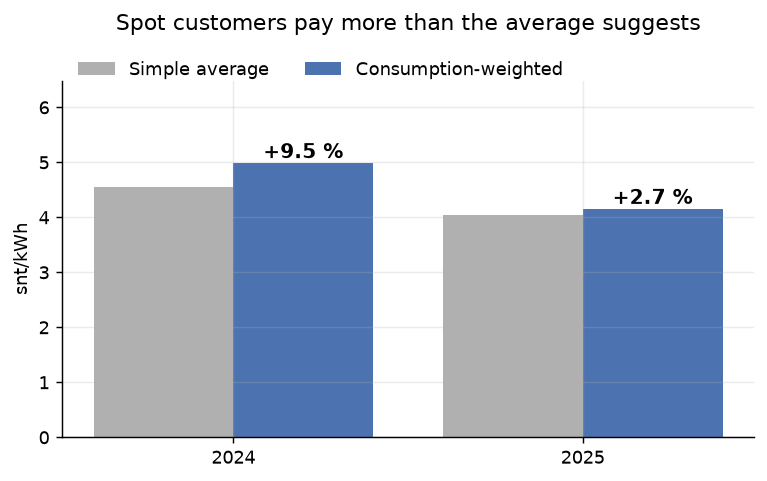

In [196]:
t = data.groupby("year")[["price_snt_kwh","consumption_mwh"]].apply(keskihinnat)

fig, ax = plt.subplots(figsize=(6, 3.8))
x = range(len(t))

ax.bar([i-0.2 for i in x], t["yksinkertainen"], 0.4,
       label="Simple average", color=HARMAA)
ax.bar([i+0.2 for i in x], t["painotettu"], 0.4,
       label="Consumption-weighted", color=V24)

for i, (_, r) in enumerate(t.iterrows()):
    ax.annotate(f"+{(r['painotettu']/r['yksinkertainen']-1)*100:.1f} %",
                (i+0.2, r["painotettu"]), ha="center", va="bottom",
                fontweight="bold", fontsize=11)

ax.set_ylim(0, t["painotettu"].max() * 1.30)
ax.set_xticks(list(x)); ax.set_xticklabels(t.index)
ax.set_ylabel("snt/kWh")
ax.set_title("Spot customers pay more than the average suggests", pad=28)
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(0, 1.10), ncol=2)

fig.tight_layout()
fig.savefig(FIG/"01_premium.png", bbox_inches="tight")

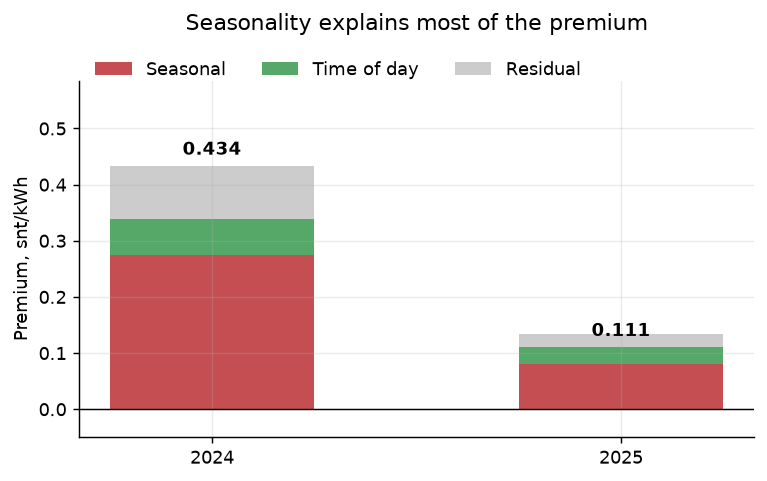

In [197]:
h = data.groupby("year")[["price_snt_kwh","consumption_mwh","hour","month"]].apply(hajota)
h["jäännös"] = h["preemio"] - h["tunti_osuus"] - h["kuukausi_osuus"]

fig, ax = plt.subplots(figsize=(6, 3.8))

pohja = 0
for sarake, vari, nimi in [("kuukausi_osuus", PUNAINEN, "Seasonal"),
                           ("tunti_osuus",    VIHREA,   "Time of day"),
                           ("jäännös",        "#CCCCCC","Residual")]:
    ax.bar(h.index.astype(str), h[sarake], 0.5, bottom=pohja, label=nimi, color=vari)
    pohja = pohja + h[sarake]

for i, v in enumerate(h.index):
    ax.annotate(f"{h.loc[v,'preemio']:.3f}", (i, h.loc[v,"preemio"] + 0.012),
                ha="center", va="bottom", fontweight="bold")

ax.axhline(0, color="black", lw=0.8)
ax.set_ylim(-0.05, h["preemio"].max() * 1.35)
ax.set_ylabel("Premium, snt/kWh")
ax.set_title("Seasonality explains most of the premium", pad=28)
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(0, 1.10), ncol=3)

fig.tight_layout()
fig.savefig(FIG/"02_decomposition.png", bbox_inches="tight")

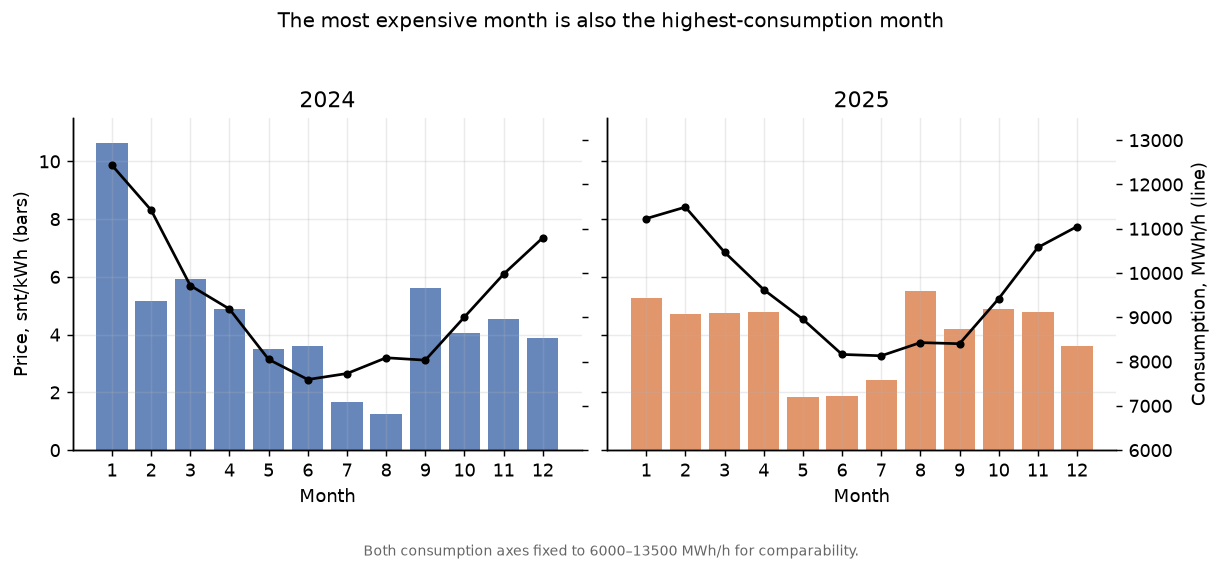

In [198]:
kk = data.groupby(["year","month"]).agg(
    hinta=("price_snt_kwh","mean"), kulutus=("consumption_mwh","mean"))

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), sharey=True)

for ax, v, vari in zip(axes, (2024, 2025), (V24, V25)):
    d = kk.loc[v]
    ax.bar(d.index, d["hinta"], color=vari, alpha=0.85, label="Price")
    ax.set_title(str(v))
    ax.set_xlabel("Month")
    ax.set_xticks(range(1, 13))
    ax.set_ylim(0, 11.5)

    ax2 = ax.twinx()
    ax2.plot(d.index, d["kulutus"], color="black", marker="o", ms=3.5,
             lw=1.5, label="Consumption")
    ax2.set_ylim(6000, 13500)
    ax2.grid(False)
    if ax is axes[1]:
        ax2.set_ylabel("Consumption, MWh/h (line)")
    else:
        ax2.set_yticklabels([])

axes[0].set_ylabel("Price, snt/kWh (bars)")
fig.suptitle("The most expensive month is also the highest-consumption month",
             y=1.04, fontsize=11)
fig.text(0.5, -0.06,
         "Both consumption axes fixed to 6000–13500 MWh/h for comparability.",
         ha="center", fontsize=8, color="#666666")

fig.tight_layout()
fig.savefig(FIG/"03_seasonal.png", bbox_inches="tight")

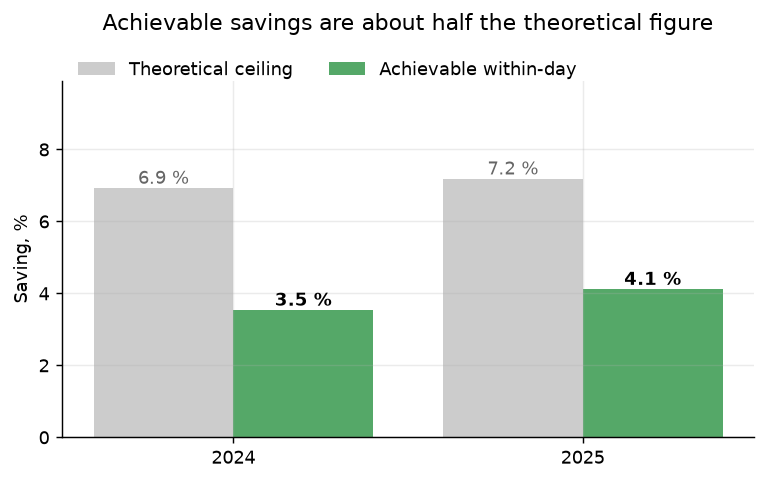

In [199]:
ylä = data.groupby("year")[["price_snt_kwh","consumption_mwh"]].apply(tuntisiirto)
vrk = data.groupby("year")[["ts","price_snt_kwh","consumption_mwh"]].apply(
          tuntisiirto_vrk, include_groups=False)

fig, ax = plt.subplots(figsize=(6, 3.8))
x = range(2)

ax.bar([i-0.2 for i in x], ylä["säästö_%"], 0.4,
       label="Theoretical ceiling", color="#CCCCCC")
ax.bar([i+0.2 for i in x], vrk["säästö_%"], 0.4,
       label="Achievable within-day", color=VIHREA)

for i in x:
    ax.annotate(f"{ylä['säästö_%'].iloc[i]:.1f} %",
                (i-0.2, ylä["säästö_%"].iloc[i]),
                ha="center", va="bottom", color="#666666")
    ax.annotate(f"{vrk['säästö_%'].iloc[i]:.1f} %",
                (i+0.2, vrk["säästö_%"].iloc[i]),
                ha="center", va="bottom", fontweight="bold")

ax.set_ylim(0, ylä["säästö_%"].max() * 1.38)
ax.set_xticks(list(x)); ax.set_xticklabels(ylä.index)
ax.set_ylabel("Saving, %")
ax.set_title("Achievable savings are about half the theoretical figure", pad=28)
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(0, 1.10), ncol=2)

fig.tight_layout()
fig.savefig(FIG/"04_savings.png", bbox_inches="tight")